# <h1><center> **Universidad Nacional Autonoma de México.** </center></h1>
# <h3><center> **Facultad de Estudios Superiores Acatlán.** </center></h3>
# <h4><center> **Tecnicas Estadisticas y Mineria de Datos** </center></h4>
# <h3><center>*Modulo IV*</center></h3>
---

# <center> *Practica: Prepocesamiento de los datos* </center>

---
**Profesor:** JAVIER ROSAS HERNÁNDEZ \\

***Grupo - 35***                $~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~$
***15 de Junio del 2025***

Antes de comenzar hay que establecer algunas paqueterias necesarios para realizar cada uno de los incisos y de paso el exporta la informacion para su previa manipulacion.

In [37]:
import numpy as np      # Manipulacion de estructuras matematicas
import pandas as pd     # Manipulacion de base de datos en tablas
import seaborn as sns   # Creacion de graficas estadisticas
import matplotlib.pyplot as plt   # Creacion de las graficas descriptivas en general.

# $\color{Blue}{\text{Primer Problema}}$

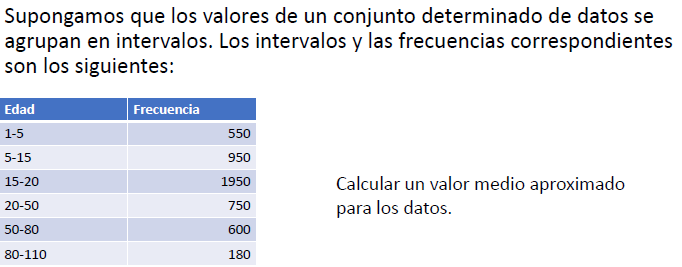

$ \color{red}{\text{Solucion:}} $

Vamos almacenar los datos del ejercicio en un tabla; pero vamos a analizar la situacion. Recordemos que **el valor medio** no es mas que un promedio de los datos; el detalle recai en el hecho de que las frecuencias son extraidos der un intervalo y por ende no podemos establecer un numero de observaciones.

Para ello lo vamos a sustituir por **el promedio ponderado** que es practicamente lo mismo, solo los datos tiene un pesos $ w_i $ ante los demas y lo podemos ver como:

$$ \frac{\sum w_i x_i}{\sum x_i} $$

Para el caso de los intervalos, dicho pesos $ w_i $ se usara **el valor del medio**...

In [38]:
# Creamos la lista que almacene los datos
lista = [['1 - 5',550],['5 - 15',950],['15 - 20',1950],['20 - 50',750],['50 - 80',600],['80 - 110',180]]

# Comvertimos este objeto en tabla con la columna
Edades = pd.DataFrame(lista, columns = ['Edad','Frecuencias'])

#Visualizamos la tabla
Edades

,Edad,Frecuencias
0,1 - 5,550
1,5 - 15,950
2,15 - 20,1950
3,20 - 50,750
4,50 - 80,600
5,80 - 110,180


In [39]:
# Agregamos la columna de valor medio de cada intervalo
Edades['Valor Medio'] = [3,10,17,35,65,95]

# Ordenamos para mejor presentacion
Edades = Edades[['Edad','Valor Medio','Frecuencias']]

# Visualizamos la tabla
Edades

,Edad,Valor Medio,Frecuencias
0,1 - 5,3,550
1,5 - 15,10,950
2,15 - 20,17,1950
3,20 - 50,35,750
4,50 - 80,65,600
5,80 - 110,95,180


Nadamas pasamos a realizar el promedio....

In [40]:
# Realizamos la suma en ambas partes de la division...

dividendo = (Edades['Valor Medio'] * Edades['Frecuencias']).sum()
divisor = Edades['Frecuencias'].sum()

# Calculamos el promedio
print(f"El valor medio de los datos sera: {(dividendo / divisor).round(3)}")


El valor medio de los datos sera: 25.432


# $\color{Blue}{\text{Segundo Problema}}$

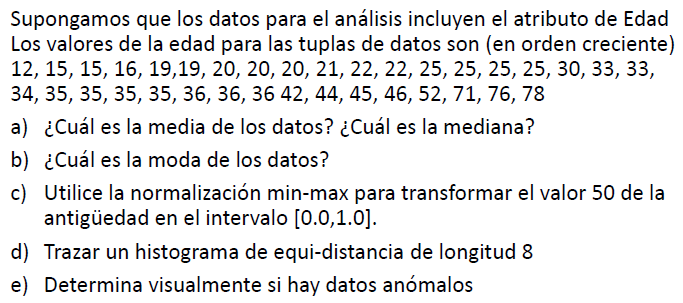

$ \color{red}{\text{Solucion:}} $

Vamos crear una lista que almacene los datos y despues en una tabla *(para mayor comodidad)*.

In [41]:
# Creamos la lista y los ordenamos
D_V = [12,16,21,30,34,42,44,45,46,52,71,76,78] + [15]*2 + [19]*2 + [20]*3 + [22]*2 + [25]*4 + [33]*2 + [35]*4 + [36]*3
D_V = sorted(D_V)

# Visualizamos la lista
print(D_V)

# Comvertimos este objeto en tabla con la columna
D_V = pd.DataFrame(D_V, columns = ['Edad'])

[12, 15, 15, 16, 19, 19, 20, 20, 20, 21, 22, 22, 25, 25, 25, 25, 30, 33, 33, 34, 35, 35, 35, 35, 36, 36, 36, 42, 44, 45, 46, 52, 71, 76, 78]


Para el **inciso a) y b)** lo podemos resolver por el siguiente codigo...

In [42]:
# Para la media
media1 = D_V['Edad'].mean()

# Para la mediana
mediana1 = D_V['Edad'].median()

# Para la moda
moda1 = D_V['Edad'].mode()

# Visualizamos los resultados
print("Podemos concluir que:")
print(f"la media es: {media1.round(4)}")
print(f"la mediana: {int(mediana1)}")
print(f"la moda: {moda1.values}")

Podemos concluir que:
la media es: 32.9429
la mediana: 33
la moda: [25 35]


Para el **inciso c)** vamos agregar una nueva columna a la tabla base con ***los datos normalizacion***.

Recordemos se aplica la siguiente formula:

$$ \frac{x_i - Min(x_i)}{Max(x_i) - Min(x_i)} $$

El codigo quedaria como:

In [43]:
D_V['Normalizacion'] = ((D_V['Edad'] - D_V['Edad'].min()) / (D_V['Edad'].max() - D_V['Edad'].min())).round(4)

# Visualizamos los datos
D_V.head(8)

,Edad,Normalizacion
0,12,0.0000
1,15,0.0455
2,15,0.0455
3,16,0.0606
4,19,0.1061
5,19,0.1061
6,20,0.1212
7,20,0.1212


In [44]:
# Veamos que los extremos sean 0 y 1
Normal_min = D_V['Normalizacion'] == D_V['Normalizacion'].min()
Normal_max = D_V['Normalizacion'] == D_V['Normalizacion'].max()

# Visualizamos los datos
print(D_V[Normal_min])
print(D_V[Normal_max])

   Edad  Normalizacion
0    12            0.0
    Edad  Normalizacion
34    78            1.0


Para finalizar este inciso, vamos a ver como quedaria normalizado el dato $50$ y dado a que este no es ni el minimo, ni el maximo en el conjunto de datos...

In [45]:
Dato_50 = (50 - D_V['Edad'].min()) / (D_V['Edad'].max() - D_V['Edad'].min())
Dato_50

0.5757575757575758

Para el caso de la grafica del histograma del **inciso d)**, sera de 2 forma distintas:

*   Para los datos originales

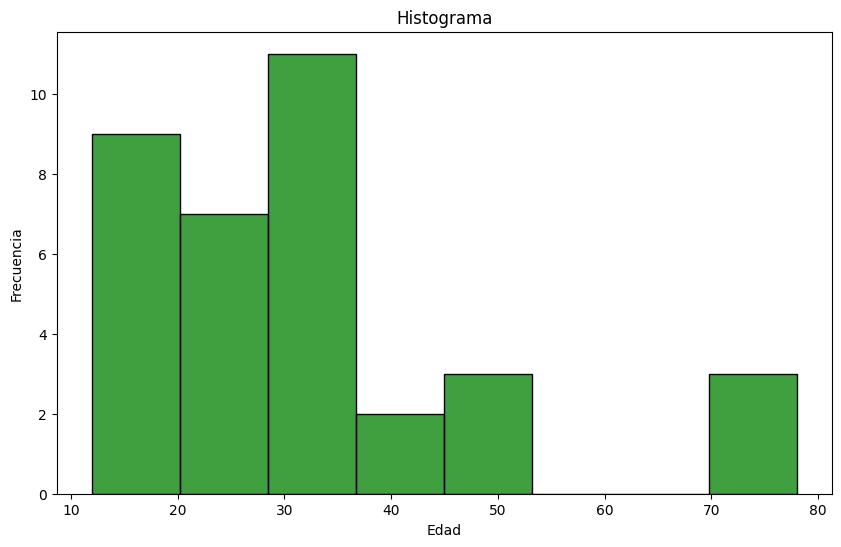

In [46]:
# Establecemos el tamano del lienzo
plt.figure(figsize = (10, 6))

# Codificamos los datos en el histograma
sns.histplot(D_V['Edad'], bins = 8, kde = False, color = 'green')

# Configuramos los elemento
plt.title("Histograma")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

# Visualizamos la grafica
plt.show()

*   Para los datos Normalizados

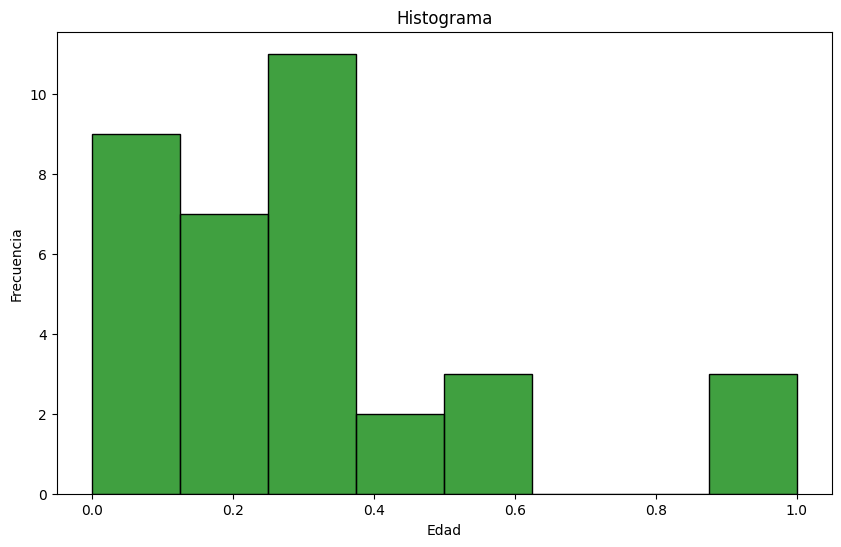

In [47]:
# Establecemos el tamano del lienzo
plt.figure(figsize = (10, 6))

# Codificamos los datos en el histograma
sns.histplot(D_V['Normalizacion'], bins = 8, kde = False, color = 'green')

# Configuramos los elemento
plt.title("Histograma")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

# Visualizamos la grafica
plt.show()

Es practicamente la misma, con la diferencia es que los datos son mas reducidos...

Podemos detectar que algunos datos esta lejos de aquellos que estan acumulados *(indicio de datos anomalos)*. Para corrobarar si hay o no **Datos Anomalos** *(inciso e) )* lo veremos **una grafica Box**...

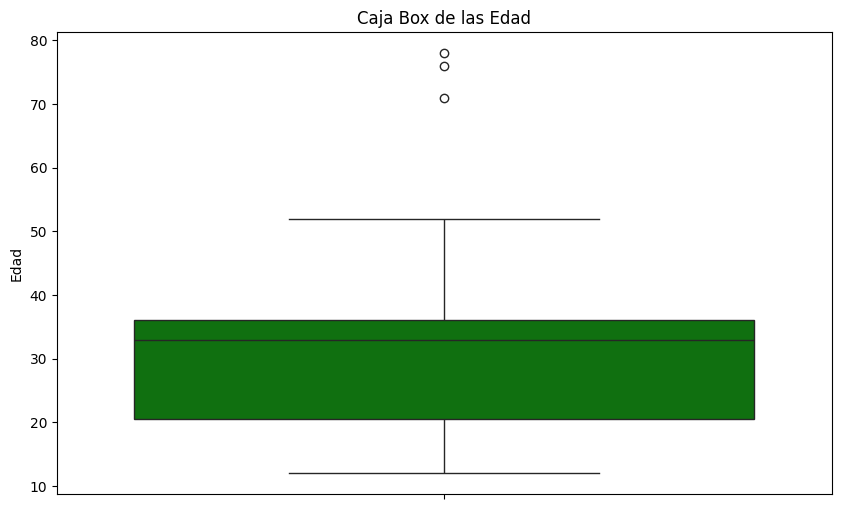

In [48]:
# Establecemos el tamano del lienzo
plt.figure(figsize = (10, 6))

# Codificamos los datos en la grafica box
sns.boxplot(D_V['Edad'], color = 'green')

# Configuramos los elemento
plt.title("Caja Box de las Edad")
plt.ylabel("Edad")

# Visualizamos la grafica
plt.show()

Podemos detectar que hay 3 valores que esta fuera del conjunto y veamos cuales son estos datos *(curiosamente son los ultimos datos)*.

In [49]:
D_V.tail(5)

,Edad,Normalizacion
30,46,0.5152
31,52,0.6061
32,71,0.8939
33,76,0.9697
34,78,1.0000


De los ultimos 3 registros podemos ver que hay un salto de valores; y por ende, son distinto a la mayoria de los demas.

# $\color{Blue}{\text{Tercer Problema}}$

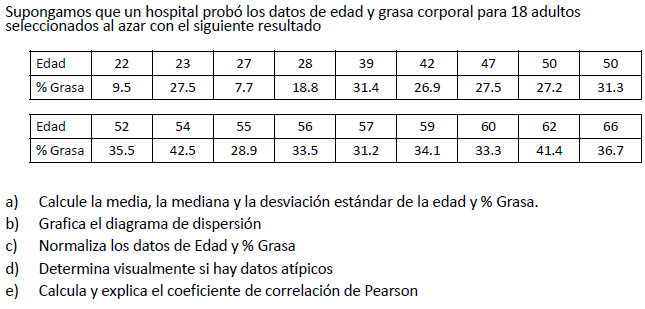

$ \color{red}{\text{Solucion:}} $

Almacenamos los datos en un objeto en una tabla *(para mejor comodidad)*

In [50]:
# Creamos la lista con los datos
Med_G = [(22,9.5),(23,27.5),(27,7.7),(28,18.8),(39,31.4),(42,26.9),(47,27.5),(50,27.2),(50,31.3),(52,35.5),(54,42.5),(55,28.9),(56,33.5),(57,31.2),(59,34.1),(60,33.3),(62,41.4),(66,36.7)]

# Convertimos este objeto en tabla con la columna
Med_G = pd.DataFrame(Med_G, columns = ['Edad', 'Grasa'])

# Visualizamos la tabla
Med_G

,Edad,Grasa
0,22,9.5
1,23,27.5
2,27,7.7
3,28,18.8
4,39,31.4
5,42,26.9
6,47,27.5
7,50,27.2
8,50,31.3
9,52,35.5


Para el calculo de los terminos que pide el **inciso a)** lo haremos de forma resumidad con el siguiente comando:

In [51]:
# Calculamos los terminos estadisticos clasico
Result = Med_G.describe()
Result

,Edad,Grasa
count,18.000000,18.000000
mean,47.166667,29.161111
std,13.904083,9.292194
min,22.000000,7.700000
25%,39.750000,27.275000
50%,51.000000,31.250000
75%,56.750000,33.950000
max,66.000000,42.500000


In [52]:
# Calculamos los terminos estadisticos clasico
Result = Med_G.describe()

# Quitamos las filas que no es de nuestro interes
Result.drop(['count', 'min', 'max', '25%', '75%'], inplace = True)

# Cambiamos los indice de los registro para mejor entendimiento.
Result.index = ['Media','Desviacion Estandar','Mediana (Percentil 50%)']

# Visualizamos la tabla
Result.round(4)

,Edad,Grasa
Media,47.1667,29.1611
Desviacion Estandar,13.9041,9.2922
Mediana (Percentil 50%),51.0000,31.2500


La **Grafica de dispersion** nos ayuda a resolver el **inciso b)** y a ver la tendencia de los datos que disponemos...

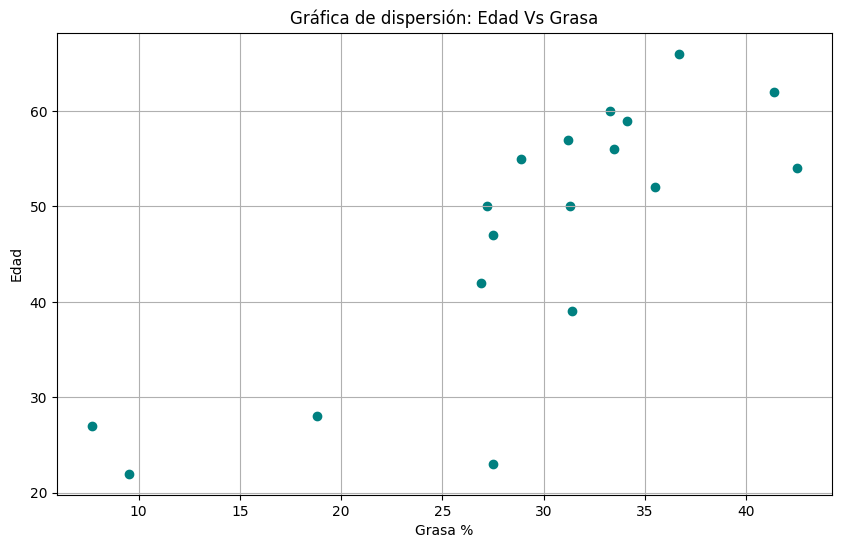

In [53]:
# Establecemos el tamano de la grafica
plt.figure(figsize = (10, 6))

# Indicamos los ejes
y = Med_G['Edad']
x = Med_G['Grasa']

# Codificamos la grafica de dispersion para la columna "D"
plt.scatter(x, y, color = 'teal')

# Configuramos loa elemento de la grafica
plt.title('Gráfica de dispersión: Edad Vs Grasa')
plt.xlabel('Grasa %')
plt.ylabel('Edad')

#Visualizamos la misma
plt.grid(True)
plt.show()

Podemos observar que hay una acumulacion de datos en la parte superior derecha *(indicio datos atipicos por su contraparte)* y train una tendencia positiva e creciente...

Por otra parte; como lo indica el **inciso c)**, veamos como nos queda los datos normalizados y ver la comparativa en la misma tabla.

In [54]:
# Realizamos los calculos
Med_G['Norm_Edad'] = ((Med_G['Edad'] - Med_G['Edad'].min()) / (Med_G['Edad'].max() - Med_G['Edad'].min())).round(4)
Med_G['Norm_Grasa'] = ((Med_G['Edad'] - Med_G['Edad'].min()) / (Med_G['Edad'].max() - Med_G['Edad'].min())).round(4)

# Ordenamos la tabla para entender mejor las comparativa
Med_G = Med_G[['Edad', 'Norm_Edad', 'Grasa', 'Norm_Grasa']]

# Visualizamos los datos
Med_G.head(8)

,Edad,Norm_Edad,Grasa,Norm_Grasa
0,22,0.0000,9.5,0.0000
1,23,0.0227,27.5,0.0227
2,27,0.1136,7.7,0.1136
3,28,0.1364,18.8,0.1364
4,39,0.3864,31.4,0.3864
5,42,0.4545,26.9,0.4545
6,47,0.5682,27.5,0.5682
7,50,0.6364,27.2,0.6364


Como en el problema anterior, vamos buscar los registros que tenga este comportamiento **Anormal a los demas**, que son como unos 4 por lo que pudimos ver en el grafica de dispersion...

*   Para el caso de la edad:

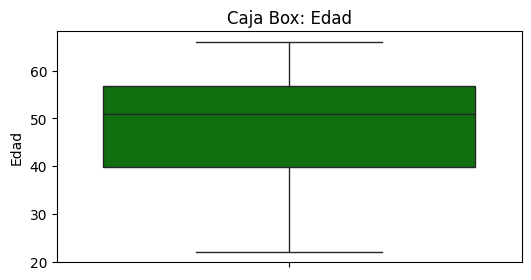

In [55]:
# Establecemos el tamano del lienzo
plt.figure(figsize = (6, 3))

# Codificamos los datos en la grafica box
sns.boxplot(Med_G['Edad'], color = 'green')

# Configuramos los elemento
plt.title("Caja Box: Edad")
plt.ylabel("Edad")

# Visualizamos la grafica
plt.show()

La grafica Box esta indicado el hecho de que este apartado, no se detecta valores anomalos.

*   Para el caso de la Grasa:

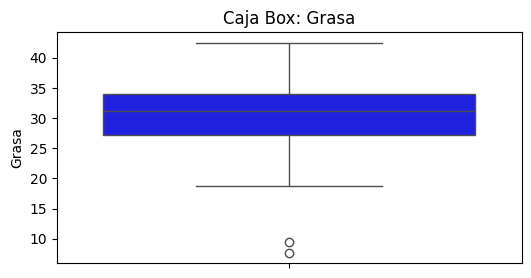

In [56]:
# Establecemos el tamano del lienzo
plt.figure(figsize = (6, 3))

# Codificamos los datos en la grafica box
sns.boxplot(Med_G['Grasa'], color = 'blue')

# Configuramos los elemento
plt.title("Caja Box: Grasa")
plt.ylabel("Grasa")

# Visualizamos la grafica
plt.show()

Esta ultima grafica, se da a entender que son 2 datos que perteneces a un registro de los cuales si son anomalos y se mas conveniente el eliminarlos. Curiosamente son los valores mas pequenos de la V.A. Grasa...

In [57]:
inf_med_G = Med_G.sort_values(by = 'Grasa')
inf_med_G.head(4)

,Edad,Norm_Edad,Grasa,Norm_Grasa
2,27,0.1136,7.7,0.1136
0,22,0.0000,9.5,0.0000
3,28,0.1364,18.8,0.1364
5,42,0.4545,26.9,0.4545


Podemos ver ese salto de valores de la columna **Grasa**; corrobarando como dato atipico...

Por ultimo; para resolver el ultimo inciso *(**inciso e)**)* daremos una explicacion de lo que es **la correlacion**.

**La correlacio:** es la relacion que existe entre 2 V.A., es decir; el cambio de valores de un conjunto de datos, afecta o altera el comportamiento de otro conjunto de datos de forma proporcional...

Por lo general; se utiliza 2 formulas de correlacion:

*   **Correlacion de Pearson**
*   **Correlacion de Spearman**

la diferencia entre las 2 es el hecho de que la primerra es mas eficiente a la hora de determinar la relacion entre 2 V.A. continua y la otra es eficiente sin importar el tipo de V.A. sea *(o como se comporte)*...

Veremos ambos casos ya que la variancion entre estos terminos no es demasiada. La forma en com interpretamos estos valores es la direccion que tome este termino $ \phi $ que vive entre $[-1,1]$

*   Si $ \phi > 0 $ hay una relacion proporcional de crecimiento entre ambas V.A.
*   Si $ \phi < 0 $ hay una relacion proporcional decreciente entre ambas V.A., es decir: si A crece, B decrece.
*   Si $ \phi = 0 $ No tiene relacion alguna o falta mas informacion para determinar este hecho.

Dado a que nos pide la correlacion de Pearson, lo podemos calcular con el siguiente codigo...

In [58]:
# Correlacion de Pearson (Coctemplando los datos originales)
matriz = Med_G.drop(['Norm_Edad','Norm_Grasa'], axis = 1).corr(method = 'pearson')
matriz

,Edad,Grasa
Edad,1.00000,0.80756
Grasa,0.80756,1.00000


En conclusion, podemos decir que la relacion entre **Edad** y **Grasa** tiene relacion positiva, de la cual si una crece en una unidad, me implica que la otra crece en un $80.7%$

# $\color{Blue}{\text{Cuarto Problema}}$

Cálculo de distancias entre atributos numéricos, de la siguientes tuplas:

*   $ X_1 = (5,3) $
*   $ X_2 = (6,10) $

Utilizando las distancias y expresar gráficamente los resultados en cada inciso:

$ \text{a) Distancia maxima} $

Recordemos que por definicion que esta distancia establece el hecho de escojer la maxima diferencia que existe *(entre parametros)* que tenga 2 tuplas. Matematicamente se escribe como:

$$ d(x_i,x_j) = Max\{ | x_{ip} - x_{jp} | \} $$

$ \color{red}{\text{Solucion:}} $

$$ \begin{align}
d(x_1,x_2) &= Max\{ | x_{11} - x_{12} |, | x_{21} - x_{22} | \} = Max\{ | 5 - 6 |, | 3 - 10 | \} \\
           &= Max\{ | -1 |, | -7 | \} = Max\{ 1, 7 \} = 7
\end{align} $$

$ \text{b) Distancia de Manhattan} $

Parecida a la anterior, solo se realiza una suma de dichas diferencias.

$$ d(x_i,x_j) = \sum_{p = 1}^{n} | x_{ip} - x_{jp} | $$

$ \color{red}{\text{Solucion:}} $

Con $ n = 2 $, tenemos que dicha distancia sera...

$$ d(x_i,x_j) = \sum_{p = 1}^{2} | x_{ip} - x_{jp} | = | x_{11} - x_{12} | + | x_{21} - x_{22} | = | 5 - 6 | + | 3 - 10 | = | -1 | + | -7 | = 1 + 7 = 8 $$


$ \color{red}{\text{Solucion:}} $

$ \text{c) Distancia de Euclidiana} $

Es la distancia mas usada *(matematicamente)* y se supone que es la distancia mas corta entre 2 puntos y lo podemos interpretar como:

$$ d^2(\mathbf{X}_i, \mathbf{X}_j) = (\mathbf{X}_i - \mathbf{X}_j)^{\mathrm{T}} (\mathbf{X}_i - \mathbf{X}_j) $$

$ \color{red}{\text{Solucion:}} $

$$ d^2(\mathbf{X}_i, \mathbf{X}_j) = \begin{bmatrix}
-1 \\
-7
\end{bmatrix} * [-1 ~ -7] = 1 + 14 = 15 $$

$$ d(\mathbf{X}_i, \mathbf{X}_j) = 3.87298 $$


# $\color{Blue}{\text{Quinto Problema}}$

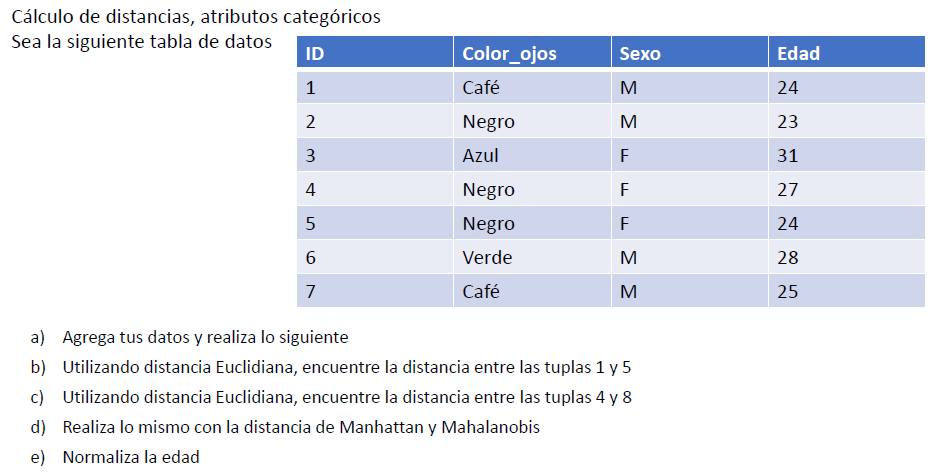

$ \color{red}{\text{Solucion:}} $

Realizando el **inciso a)** tenemos el siguiente codigo:

In [59]:
# Creamos una serie de listas que almacene los datos
ID = [1,2,3,4,5,6,7]
Color = ['Cafe','Negro','Azul','Negro','Negro','Verde','Cafe']
Sexo = ['M','M','F','F','F','M','M']
Anos = [24,23,31,27,24,28,25]

# Unificamos los valores en una tabla
tabla = pd.DataFrame({'ID':ID,'Color_ojos':Color,'Sexo':Sexo,'Edad':Anos})
tabla

,ID,Color_ojos,Sexo,Edad
0,1,Cafe,M,24
1,2,Negro,M,23
2,3,Azul,F,31
3,4,Negro,F,27
4,5,Negro,F,24
5,6,Verde,M,28
6,7,Cafe,M,25


Podemos notar; que para realizar las distancia que nos pide la actividad es necesario el cambiar las V.A. Categoricas *(Color_ojos, Sexo)* en valores numericos de los cuales podemos manipular matematicamente...

In [60]:
# Cambiamos la columna "ID" como los indices
tabla.index = tabla['ID']

# Eliminamos la misma columna
tabla.drop('ID',axis = 1,inplace = True)

# Visualizamos los cambios
tabla

,Color_ojos,Sexo,Edad
ID,,,
1,Cafe,M,24
2,Negro,M,23
3,Azul,F,31
4,Negro,F,27
5,Negro,F,24
6,Verde,M,28
7,Cafe,M,25


In [61]:
# Cambiamos las Variables categorias en Variables Numericas
tabla['Color_ojos'] = tabla['Color_ojos'].replace({'Cafe':0,'Negro':1,'Azul':2,'Verde':3})
tabla['Sexo'] = tabla['Sexo'].replace({'M':0,'F':1})

# Visualizamos los cambios
tabla

<ipython-input-61-3473081656>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tabla['Color_ojos'] = tabla['Color_ojos'].replace({'Cafe':0,'Negro':1,'Azul':2,'Verde':3})
<ipython-input-61-3473081656>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tabla['Sexo'] = tabla['Sexo'].replace({'M':0,'F':1})


,Color_ojos,Sexo,Edad
ID,,,
1,0,0,24
2,1,0,23
3,2,1,31
4,1,1,27
5,1,1,24
6,3,0,28
7,0,0,25


Vamos a resolver **los incisos b), c) y d)**. Pero para este ocasion, vamos agilizar los calculos con un paqueteria que tiene ya definido estas distancias y lo estariasmos expresando los resultados en una tabla...




In [62]:
# Traemos la funcion de "distance"
from scipy.spatial import distance

# Establecemos los registros como puntos
p1 = tabla.loc[1]
p2 = tabla.loc[5]
p3 = tabla.loc[4]
p4 = tabla.loc[7]

* **Distancia Euclidiana (funcion euclidiana):**


In [63]:
# Calculamos las distancias
d_euclidiana_1 = [distance.euclidean(p1, p2)]
d_euclidiana_2 = [distance.euclidean(p3, p4)]

* **Distancia Manhattan(funcion cityblock):**

In [64]:
# Calculamos las distancias
d_manhattan_1 = [distance.cityblock(p1, p2)]
d_manhattan_2 = [distance.cityblock(p3, p4)]

* **Distancia Maxima(funcion Chebyshev):**

In [65]:
# Calculamos las distancias
d_Maxima_1 = [distance.chebyshev(p1, p2)]
d_Maxima_2 = [distance.chebyshev(p3, p4)]

Comparamos las distancias entre si:

In [66]:
Compa = pd.DataFrame({'Distancia_Euclidiana':[d_euclidiana_1,d_euclidiana_2],'Distancia_Manhattan':[d_manhattan_1,d_manhattan_2],'Distancia_Maxima':[d_Maxima_1,d_Maxima_2]})
Compa

,Distancia_Euclidiana,Distancia_Manhattan,Distancia_Maxima
0,[1.4142135623730951],[2],[1]
1,[2.449489742783178],[4],[2]


El **inciso e)** nos indica el normalizar los datos de la edad

In [67]:
tabla['Edad_normalizada'] = (tabla['Edad']-tabla['Edad'].min())/(tabla['Edad'].max()-tabla['Edad'].min())
tabla

,Color_ojos,Sexo,Edad,Edad_normalizada
ID,,,,
1,0,0,24,0.125
2,1,0,23,0.000
3,2,1,31,1.000
4,1,1,27,0.500
5,1,1,24,0.125
6,3,0,28,0.625
7,0,0,25,0.250


# $\color{Blue}{\text{Sexto Problema}}$

Con los datos anteriores:

*   a) Calcula/genera la matriz de correlación de datos. Concluye tus resultados.

$ \color{red}{\text{Solucion:}} $

Para este punto sabemos lo que es **Correlacion** y dado a que nos pide la matriz vamos a codificarla *(junto con si Grafica de calor para observar al detalle)*..

In [68]:
# Con la Correlacion de Pearson y dejando a un lado "la edad"
matriz = tabla.drop('Edad', axis = 1).corr(method = 'pearson')
matriz.round(3)

,Color_ojos,Sexo,Edad_normalizada
Color_ojos,1.000,0.167,0.661
Sexo,0.167,1.000,0.441
Edad_normalizada,0.661,0.441,1.000


Pasando directamente con la grafica de calor..

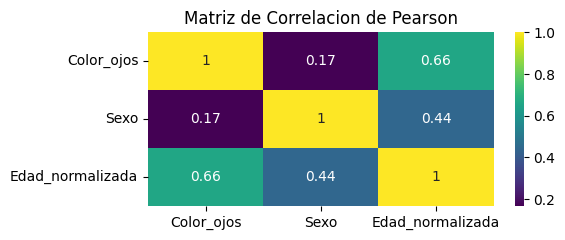

In [69]:
# Creamos el lienzo para la grafica
plt.figure(figsize = (6, 2.5))

# Sobre la gráfica de calor
sns.heatmap(matriz, annot = True, cmap = 'viridis')

# Titulo de la grafica
plt.title('Matriz de Correlacion de Pearson')

plt.tight_layout()
plt.show()

Algunas conclusiones que podemos ver son:

*   La mejor relacion entre V.A. son entre **la edad** y **el color de ojos** ya que ambas tiene un creciemiento positivo entre ambas del $0.66$.

*   La peor relacion entre V.A. son entre **Sexo** y **el color de ojos** ya que ambas tiene un creciemiento positivo muy tenue entre ambas del $0.17$ *(cercano a 0, casi no tiene alguna relacion)*.

Pareciera que ambas correlaciones, no nos proporciona mucha informacion relecante; mas el hecho de la poca intuicion que tenemos sobre que tiene que ver el color de los ojos con la edad e sexo de los registro...

Eso ya recai mas en la coherencia de los datos. Por otra parte podemos crea un modelo predictivo para determinar una valor aproximado en base a los demas V.A. y con ello podemo ver la relacion intrinsica....

*   b) Elaborar un modelo de regresión lineal, expresión lineal. Concluye tus resultados.

$ \color{red}{\text{Solucion:}} $

Un modelo de ***Regresion lineal*** sera una expresion matematica que estara determinado una pendienten central *(Esperanza condicional matematica de Y|x)* en los datos y con ella podemos dar predecir el valor especifico *(V.A. Dependiente)* en base a otros valores *(V.A. Explicativa)*.

Para este caso; matematicamente la recta de regresion sera de la forma:

$$ Y = \beta_0 + x_1 \beta_1 + x_2 \beta_2 + e $$

Donde las betas sera conocidad como: **Coeficiente de x** y hay veces en la que analizar esto terminos, se puede determinar si hay *(o no)* del descarta una V.A.

In [70]:
# Traemos las paqueteria diseñada para este tipo de modelos
import statsmodels.api as sm

# Preparamos el modelo de regresion lineal por el metodo de los "Minimos Cuadrado Ordinarios" (OLS)
modelo = sm.OLS(tabla['Color_ojos'], sm.add_constant(tabla[['Edad_normalizada', 'Sexo']]))

# Ajustamos el modelo con los datos
resultados = modelo.fit()

Para este caso vamos proponer como:

*   V.A. DEPENDIENTE Y = "Color_ojos"
*   V.A. EXPLICATICA X = "Edad_nomalizada", "Sexo"

Por el simple hecho de que las matriz de correlacion anterior arrojaba buenos resultados con esta V.A.

y para averiguar si nuestro modelo es eficiente o no, por medio de una analisis rapido del **Summery**...

In [71]:
print(resultados.summary())

                            OLS Regression Results                            
Dep. Variable:             Color_ojos   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     1.683
Date:                Wed, 18 Jun 2025   Prob (F-statistic):              0.295
Time:                        05:10:43   Log-Likelihood:                -7.7238
No. Observations:                   7   AIC:                             21.45
Df Residuals:                       4   BIC:                             21.29
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.4483      0.574  

/usr/local/lib/python3.11/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


Hay muchos conclusiones que podemos sacar de este resumen del modelo, pero lo haremos parte por parte...

## $ \color{Green}{\text{Sobre los coeficiente}} $

Matematicamente tenemos que la pendiente de regresion se ve de la forma:

$$ Y = 0.4483 + 2.2069 \cdot x_1 + -0.3103 \cdot x_2 + e $$

El analisis sobre el estado de los coeficientes se parte en 2 pruebas:

*  **Una prueba de hipotesis:** Indica si es significativo el coeficiente o no en modelo de regresion; y eso se realiza por medio de una *P_Value* $ (P>|t|) $. Diremos que si vale la pena utilizar si es menor al $ 0.05 $. Pero como no es el caso. Se recomienda ver otros datos.

*  **Intervalo de confianza:** Sera el conjunto de valores que puede tomar el coeficiente y podemos estar seguro que el coeficiente es significativo si no contiene al cero *(pero tambien falla en este aspecto)*.

## $ \color{Green}{\text{Sobre el error}} $

En la ecuacion se vio una V.A. $e$ que no es mas que el error que seria la diferencia entre el valor real y el valor estimado; es decir,

$$ e = \hat{Y} - Y $$

Podemos decir que el error no interviene o afecta a las resultados sera si este **ruido blanco** que esta V.A. se comporta como la distribucion normal de la forma: $ N(0,\sigma) $.

Podemos ver que tiene este comportamiento por partes:

*  **su grafica de la distribucion:** Con los coeficientes *(sesgo debe de estar 0 o cerca)* **Skew: 0.201** y *(Curtosis que de estar cerca del 3)* **Kurtosis: 1.712**. Por ende, no no tiene comportamiento de una normal.

*  **Prueba de hipotesis de Normalidad:** Para este la prueba jarque-bera y es muy parecidad a la prueba anterior y por ende dado a que no es menor al $0.05$ podemos concluir que el error no se aproxima a una distribucion normal.

## $ \color{Green}{\text{Conclusion en General}} $

Podemos decrie que el modelo no es eficiente como sistema predictivo tanto en sus aspectos mas fundamentales como  en su $ R^2 $ *(Coeficiente de determinacion)*, que no es mas el parametro definitivo de cual nos indica el $%$ en las el modelo se ajuste a los datos. Si el nuestro es del $ 45.6% $ y por ello debemos de buscar mas datos que nos proporciones mas informacion, al igual que dar otro parametros de eficiente *(partiendo los datos en entrenamiento y test)*